In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s5e10/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e10/train.csv
/kaggle/input/competitions/playground-series-s5e10/test.csv


In [2]:
train =pd.read_csv('/kaggle/input/competitions/playground-series-s5e10/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s5e10/test.csv')

print(f'Размер тренировочной выборки = {train.shape}')
print(f'Размер тестовой выборки = {test.shape}')

Размер тренировочной выборки = (517754, 14)
Размер тестовой выборки = (172585, 13)


# Обработка данных

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [4]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
bool_cols = train.select_dtypes(include='bool').columns.tolist()
print(f'Категориальные признаки: {cat_cols}\nЧисловые признаки: {num_cols}\nБулевые переменные: {bool_cols}' )

Категориальные признаки: ['road_type', 'lighting', 'weather', 'time_of_day']
Числовые признаки: ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
Булевые переменные: ['road_signs_present', 'public_road', 'holiday', 'school_season']


In [5]:
target = 'accident_risk'

In [6]:
import matplotlib.pyplot as plt

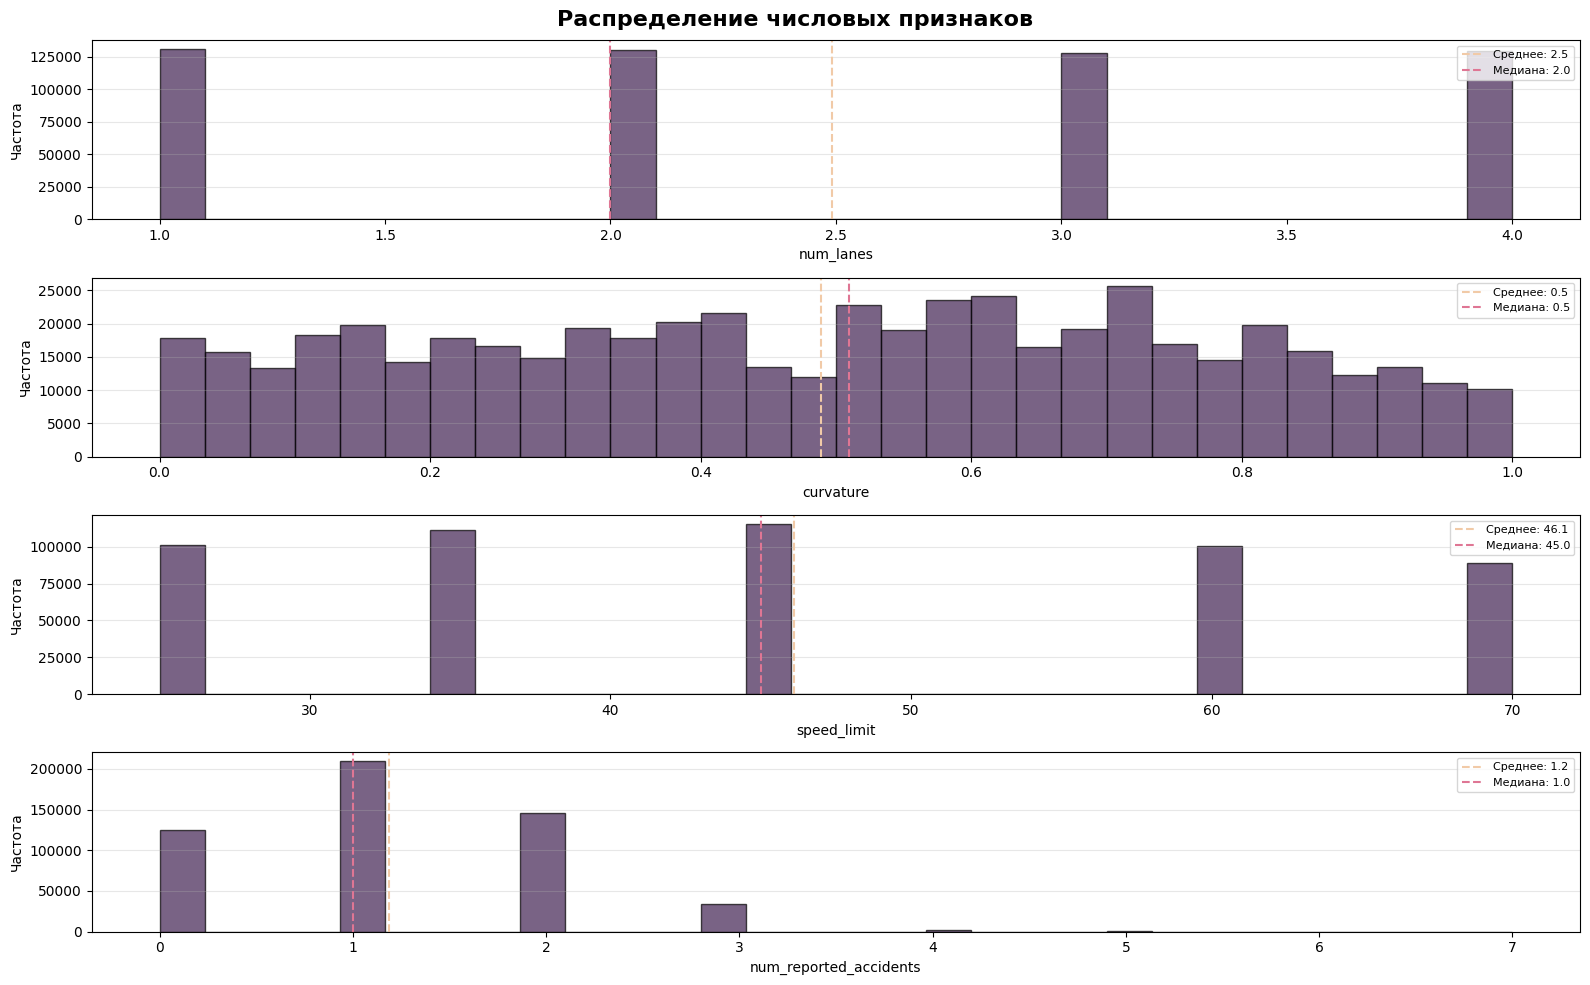

In [7]:
#Числовые признаки
fig, axes = plt.subplots(4, 1, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Распределение числовых признаков', fontsize=16, fontweight='bold')

for idx, col in enumerate(num_cols):
    axes[idx].hist(train[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='#412151')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(axis='y', alpha=0.3)

    mean_val = train[col].mean()
    median_val = train[col].median()
    axes[idx].axvline(mean_val, color='#F1CAA7', linestyle='--', label=f'Среднее: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='#DF7694', linestyle='--', label=f'Медиана: {median_val:.1f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

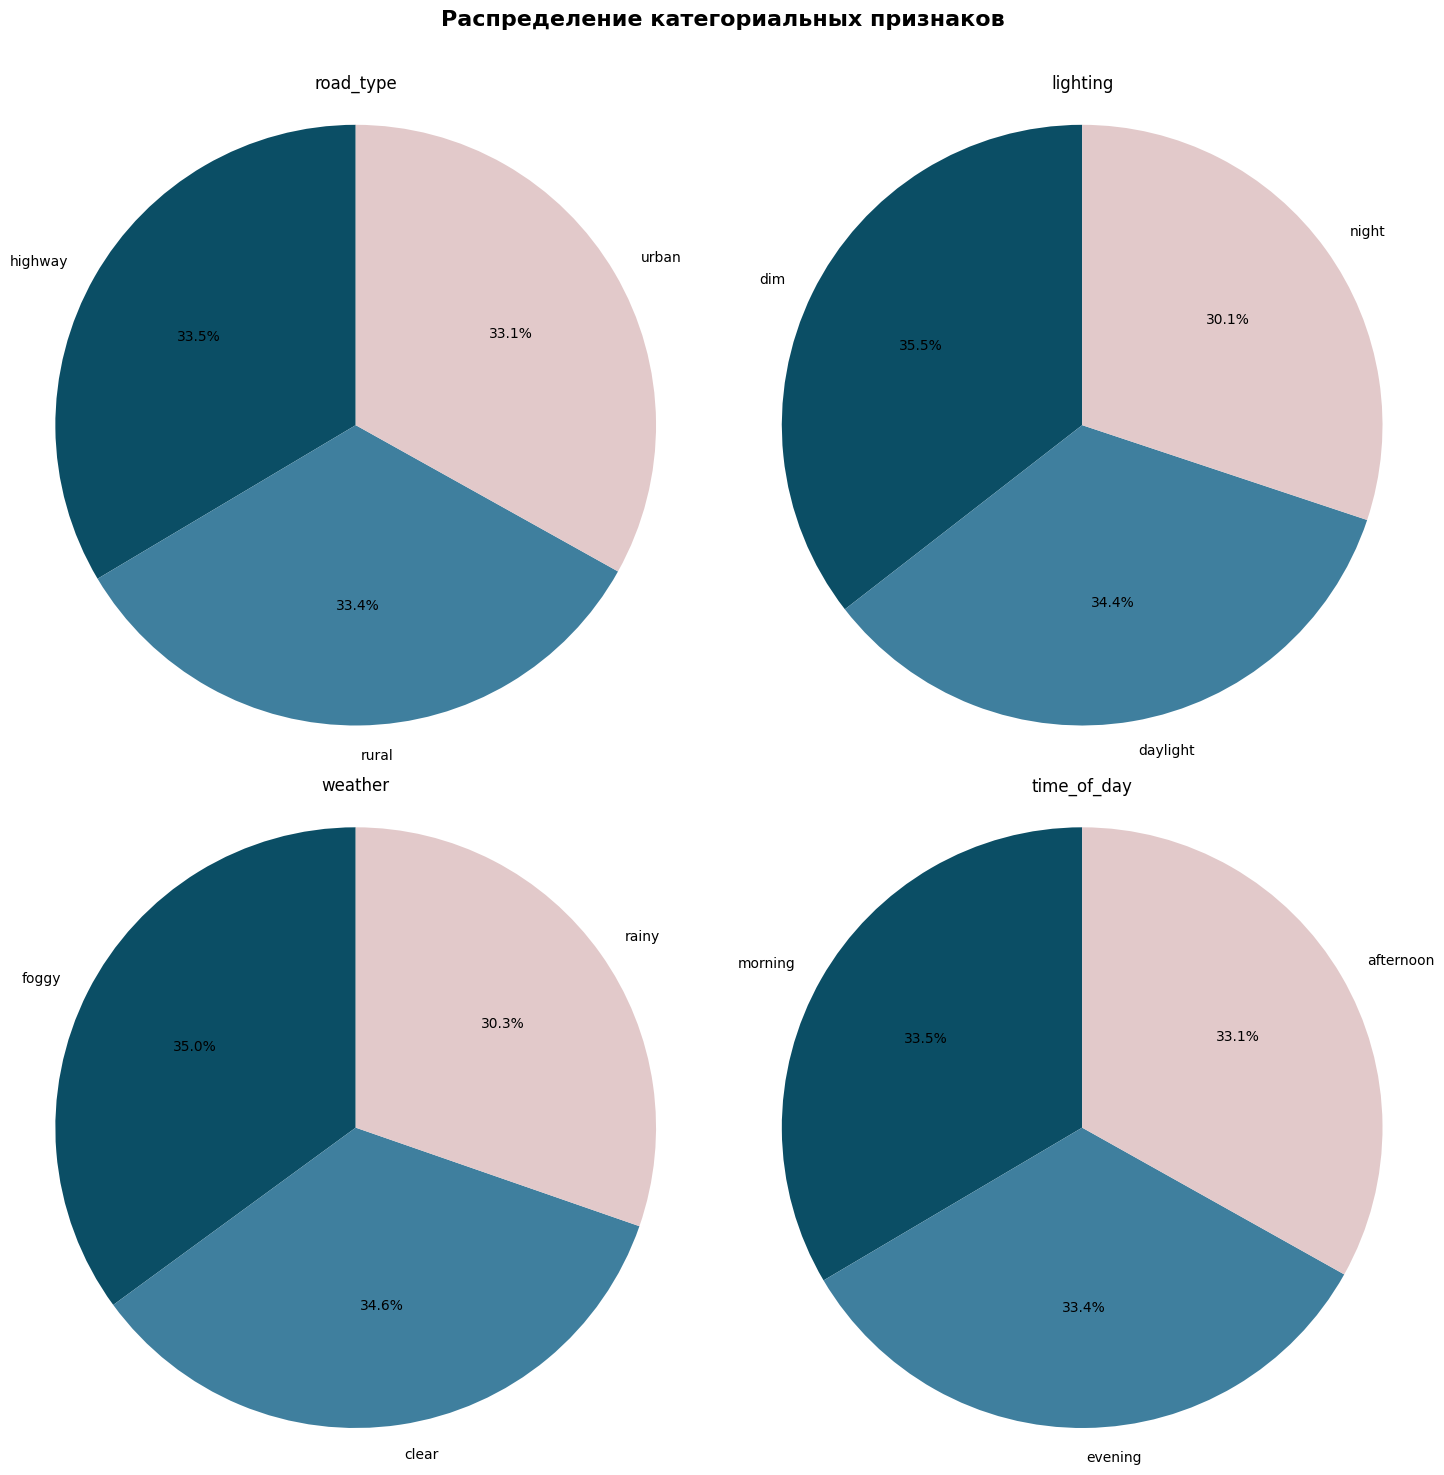

In [8]:
# Категоральные признаки
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Распределение категориальных признаков', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()

for idx, col in enumerate(cat_cols):
    value_counts = train[col].value_counts()
    
    axes_flat[idx].pie(value_counts.values,
                  labels=value_counts.index,
                  autopct='%1.1f%%',
                  startangle=90,
                  colors=['#0B4E65','#3F7F9E','#E2C9CA','#D8A996','#B47C50'])
    axes_flat[idx].set_title(col)
    axes_flat[idx].axis('equal')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

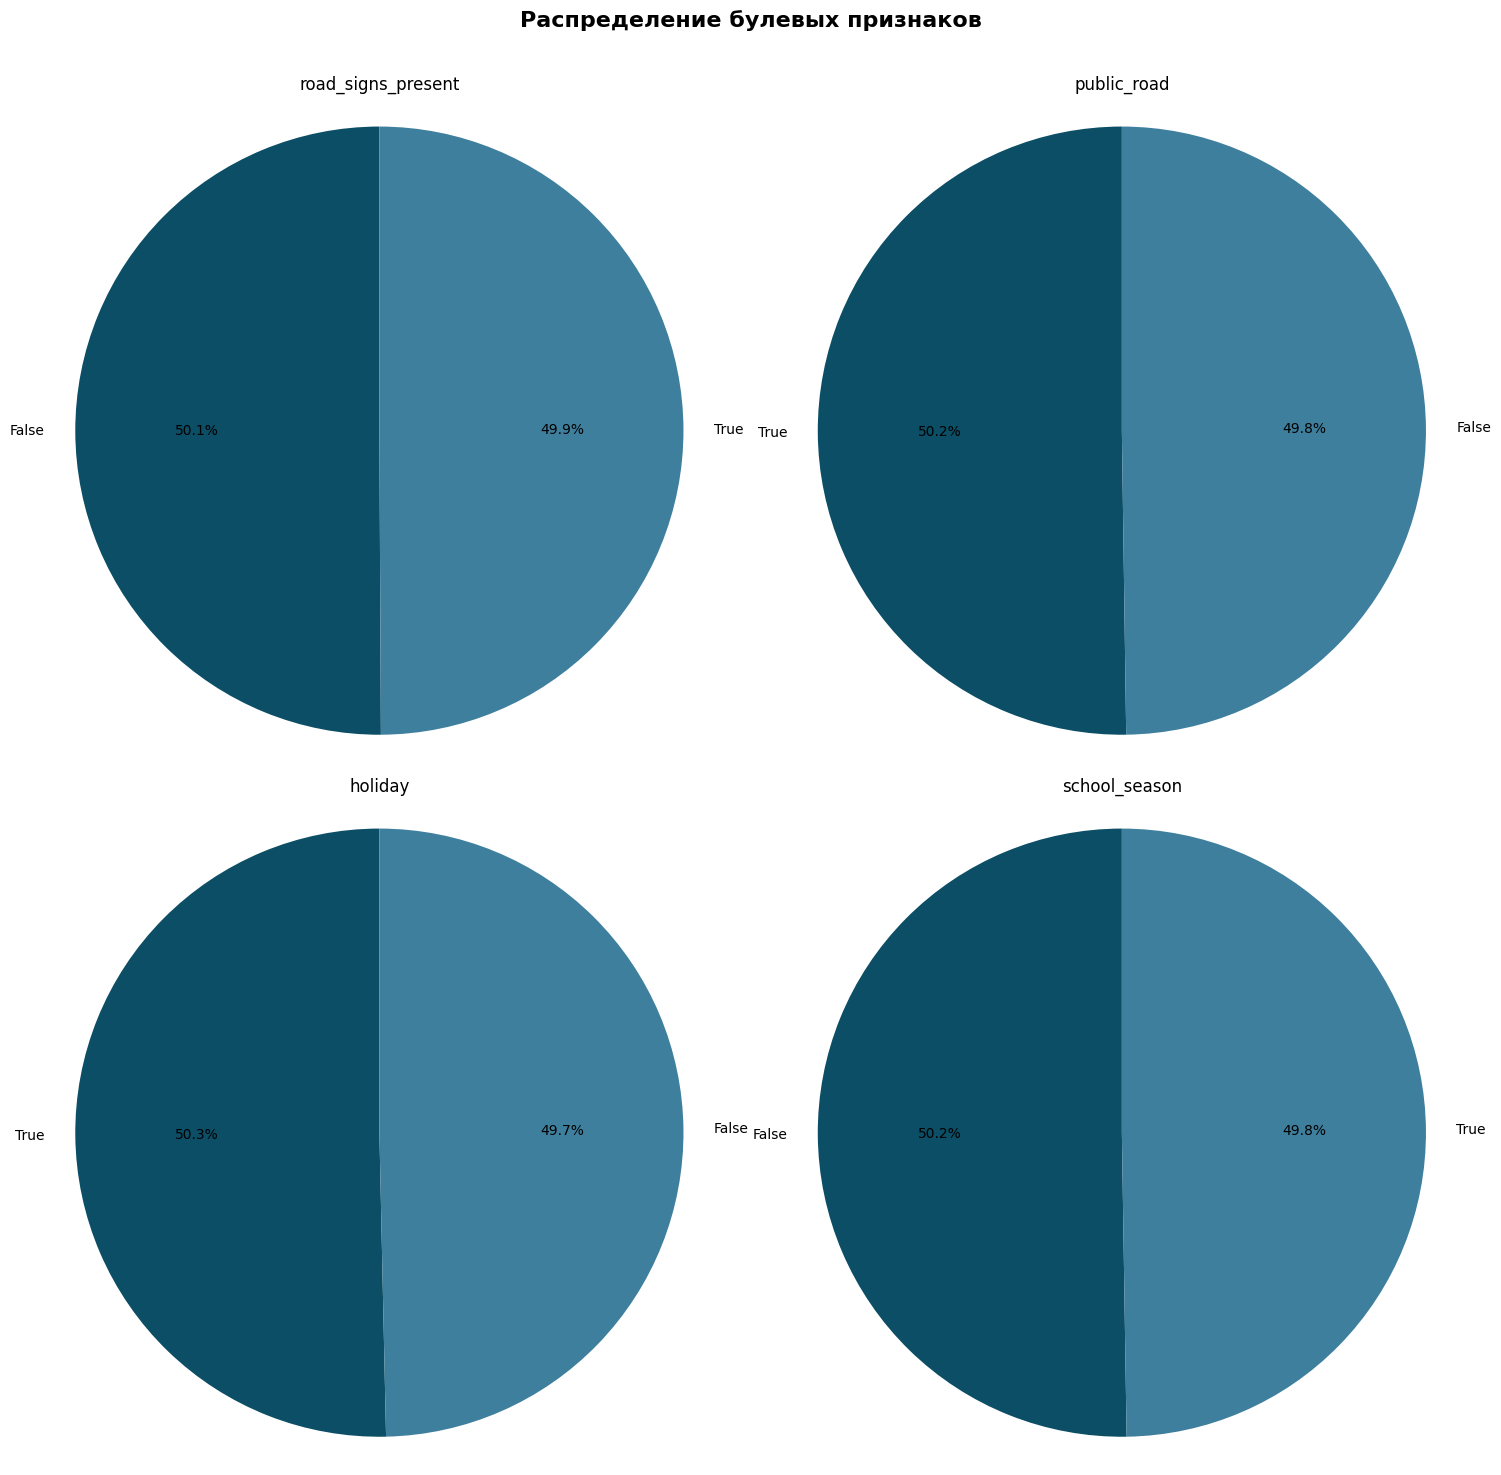

In [9]:
# Булевые признаки
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Распределение булевых признаков', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()

for idx, col in enumerate(bool_cols):
    value_counts = train[col].value_counts()
    
    axes_flat[idx].pie(value_counts.values,
                  labels=value_counts.index,
                  autopct='%1.1f%%',
                  startangle=90,
                  colors=['#0B4E65','#3F7F9E','#E2C9CA','#D8A996','#B47C50'])
    axes_flat[idx].set_title(col)
    axes_flat[idx].axis('equal')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

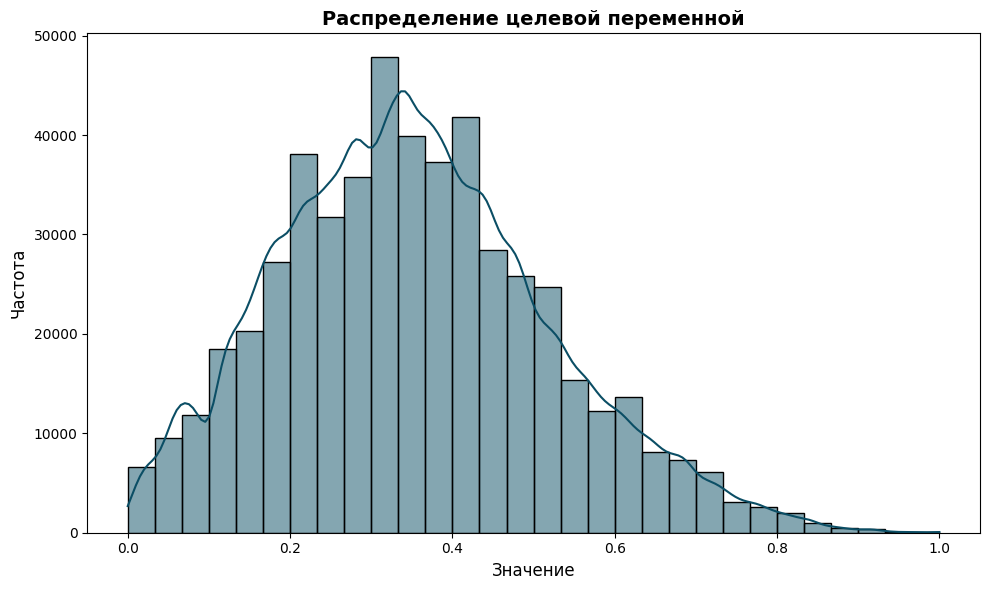

In [10]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

# Гистограмма с ядерной оценкой плотности (KDE)
sns.histplot(data=train, x=target, bins=30, kde=True, color='#0B4E65')

ax.set_title('Распределение целевой переменной', fontsize=14, fontweight='bold')
ax.set_xlabel('Значение', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)

plt.tight_layout()
plt.show()

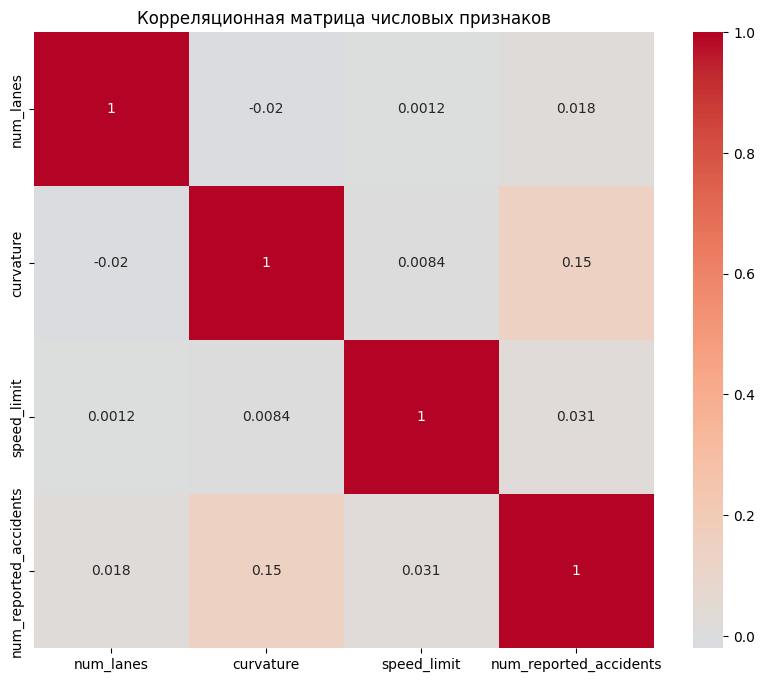

🔎 Аномалии по методу IQR:
num_lanes: 0 аномалий (0.00%), диапазон: [-2.00, 6.00]
curvature: 0 аномалий (0.00%), диапазон: [-0.41, 1.38]
speed_limit: 0 аномалий (0.00%), диапазон: [-2.50, 97.50]
num_reported_accidents: 2649 аномалий (0.51%), диапазон: [-0.50, 3.50]

📈 Тест на нормальность (Shapiro-Wilk):
curvature: p-value = 0.0000 → НЕ нормальное


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Корреляционная матрица для числовых признаков
plt.figure(figsize=(10, 8))
sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

# 2. Проверка на аномалии через IQR для каждого числового признака
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), lower, upper

print("🔎 Аномалии по методу IQR:")
for col in num_cols:
    count, low, high = detect_outliers_iqr(train, col)
    print(f"{col}: {count} аномалий ({count/len(train)*100:.2f}%), диапазон: [{low:.2f}, {high:.2f}]")

# 3. Тест Шапиро-Уилка на нормальность (для непрерывных признаков)
print("\n📈 Тест на нормальность (Shapiro-Wilk):")
for col in ['curvature']:  # только для потенциально непрерывных
    stat, p_value = stats.shapiro(train[col].sample(5000))  # сэмплим для скорости
    print(f"{col}: p-value = {p_value:.4f} → {'Нормальное' if p_value > 0.05 else 'НЕ нормальное'}")

# Линейная модель

In [12]:
#Давайте попробуем обучиться на линейной моделе
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# 1. Подготовка данных
X = train.drop(columns=[target, 'id'])
y = train[target]

# Определяем типы колонок
num_cols = ['num_lanes']
cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day','curvature', 'speed_limit', 'num_reported_accidents']
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']

# 2. Создаем предобработчик (Preprocessor)
# Для чисел используем RobustScaler (хорошо работает с выбросами)
# Для категорий используем OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough' # Булевы признаки останутся без изменений
)

# 3. Создаем пайплайн (Pipeline)
# Пайплайн последовательно применяет preprocessor, а затем модель
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0)) # alpha - сила регуляризации
])

# 4. Разбиваем на train/val для быстрой проверки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Обучаем модель
print("⏳ Обучение модели...")
model.fit(X_train, y_train)

# 6. Оценка качества на валидации
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"✅ RMSE на валидации: {rmse:.4f}")

# 7. Кросс-валидация (более надежная оценка)
print("\n🔄 Запуск кросс-валидации (5 фолдов)...")
# negative_root_mean_squared_error вернет отрицательное значение, берем модуль
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"📊 Средний RMSE (CV): {-np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

⏳ Обучение модели...
✅ RMSE на валидации: 0.0578

🔄 Запуск кросс-валидации (5 фолдов)...
📊 Средний RMSE (CV): 0.0577 (+/- 0.0003)


# RandomForest

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.metrics import balanced_accuracy_score
import time

print("🌲 Начинаем обучение RandomForest...")
start_time = time.time()

# Пайплайн: препроцессинг + модель
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=500,          # Количество деревьев (можно увеличить до 300+)
        criterion =  'friedman_mse',
        max_depth=12,              # Глубина деревьев (регуляризация переобучения)
        min_samples_split=5,       # Мин. кол-во объектов для разделения узла
        min_samples_leaf=4,        # Мин. кол-во объектов в листе
        n_jobs=-1,                 # Используем все ядра CPU
        random_state=42
    ))
])

# Обучение
rf_pipeline.fit(X_train, y_train)

# Предсказание и оценка
y_pred = rf_pipeline.predict(X_val)
train_time = time.time() - start_time
print(f"⏱ Время обучения: {train_time:.2f} сек")
print(f"✅ RMSE на валидации: {np.sqrt(mean_squared_error(y_val, y_pred))}")

🌲 Начинаем обучение RandomForest...
⏱ Время обучения: 1734.39 сек
✅ RMSE на валидации: 0.08934162363633952


#  XGBoost

In [14]:
import time
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import xgboost as xgb

print("🌲 Начинаем обучение XGBoost...")
start_time = time.time()

# Пайплайн: препроцессинг + модель
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=1500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,      # L1 регуляризация
        reg_lambda=1.0,     # L2 регуляризация
        random_state=42,
        tree_method='hist', # Быстрый алгоритм для больших датасетов
        n_jobs=-1,
        eval_metric='rmse'  # Лучше передавать в конструктор (избегает warning в XGBoost >=1.6.0)
    ))
])

# Обучение с early stopping
xgb_pipeline.fit(X_train, y_train)

# Предсказание и оценка
y_pred = xgb_pipeline.predict(X_val)
train_time = time.time() - start_time

print(f"\n⏱ Время обучения: {train_time:.2f} сек")
print(f"✅ RMSE на валидации: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

🌲 Начинаем обучение XGBoost...

⏱ Время обучения: 99.89 сек
✅ RMSE на валидации: 0.0568


# CatBoost

In [15]:
import time
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

print("🐱 Начинаем обучение CatBoost...")
start_time = time.time()

# Пайплайн: препроцессинг + модель
cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', CatBoostRegressor(
        iterations= 1500,          # Кол-во деревьев (итераций)
        learning_rate=0.05,       # Скорость обучения
        depth=6,                  # Глубина деревьев
        l2_leaf_reg=1.0,          # L2 регуляризация (аналог weight_decay)
        subsample=0.8,            # Доля строк для обучения каждого дерева
        colsample_bylevel=0.8,    # Доля признаков для каждого уровня дерева
        random_state=42,
        verbose=100,              # Вывод лога каждые 100 итераций
        thread_count=-1,          # Все ядра CPU
        loss_function='RMSE'      # Целевая метрика
    ))
])

# Обучение
cat_pipeline.fit(X_train, y_train)

# Предсказание и оценка
y_pred = cat_pipeline.predict(X_val)
train_time = time.time() - start_time

print(f"\n⏱ Время обучения: {train_time:.2f} сек")
print(f"✅ RMSE на валидации: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

🐱 Начинаем обучение CatBoost...
0:	learn: 0.1610598	total: 91.9ms	remaining: 2m 17s
100:	learn: 0.0830220	total: 2.8s	remaining: 38.8s
200:	learn: 0.0711669	total: 5.35s	remaining: 34.6s
300:	learn: 0.0652185	total: 7.87s	remaining: 31.3s
400:	learn: 0.0618820	total: 10.4s	remaining: 28.5s
500:	learn: 0.0599551	total: 13s	remaining: 25.9s
600:	learn: 0.0588041	total: 15.5s	remaining: 23.2s
700:	learn: 0.0580993	total: 18.1s	remaining: 20.6s
800:	learn: 0.0576331	total: 20.7s	remaining: 18s
900:	learn: 0.0572961	total: 23.3s	remaining: 15.5s
1000:	learn: 0.0570340	total: 25.9s	remaining: 12.9s
1100:	learn: 0.0568517	total: 28.5s	remaining: 10.3s
1200:	learn: 0.0567085	total: 31.2s	remaining: 7.77s
1300:	learn: 0.0565943	total: 33.9s	remaining: 5.18s
1400:	learn: 0.0564916	total: 36.5s	remaining: 2.58s
1499:	learn: 0.0564088	total: 39.1s	remaining: 0us

⏱ Время обучения: 44.88 сек
✅ RMSE на валидации: 0.0569


In [16]:
# 1. Подготавливаем тестовые данные (убираем только id, признаки остаются)
X_test = test.drop(columns=['id'])

# 2. Делаем предсказания
print("🔮 Делаем предсказания на тестовых данных...")
test_predictions = cat_pipeline.predict(X_test)

# 3. Формируем DataFrame для отправки
submission = pd.DataFrame({
    'id': test['id'],
    'accident_risk': test_predictions
})

# 4. Сохраняем в CSV и смотрим результат
submission.to_csv('submission_catboost.csv', index=False)
print("✅ Файл submission_catboost.csv успешно сохранен в /kaggle/working/")
display(submission.head(10))

🔮 Делаем предсказания на тестовых данных...
✅ Файл submission_catboost.csv успешно сохранен в /kaggle/working/


,id,accident_risk
0,517754,0.299087
1,517755,0.121815
2,517756,0.189643
3,517757,0.354401
4,517758,0.410901
5,517759,0.448210
6,517760,0.260100
7,517761,0.202702
8,517762,0.376419
9,517763,0.311732


# LightGBM

In [17]:
import lightgbm as lgb


print("💡 Начинаем обучение LightGBM...")
start_time = time.time()

# Пайплайн: препроцессинг + модель
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(
        n_estimators=1500,          # Кол-во деревьев
        learning_rate=0.05,         # Скорость обучения
        max_depth=6,                # Глубина деревьев
        subsample=0.8,              # Доля строк для обучения каждого дерева
        colsample_bytree=0.8,       # Доля признаков для каждого дерева
        reg_alpha=0.1,              # L1 регуляризация
        reg_lambda=1.0,             # L2 регуляризация
        random_state=42,
        n_jobs=-1,                  # Все ядра CPU
        verbose=-1                  # Отключение логов (verbose=0 в новых версиях)
    ))
])

# Обучение
lgbm_pipeline.fit(X_train, y_train)

# Предсказание и оценка
y_pred = lgbm_pipeline.predict(X_val)
train_time = time.time() - start_time

print(f"\n⏱ Время обучения: {train_time:.2f} сек")
print(f"✅ RMSE на валидации: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

💡 Начинаем обучение LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



⏱ Время обучения: 21.41 сек
✅ RMSE на валидации: 0.0573


# Стекинг

In [18]:
from sklearn.ensemble import StackingRegressor

print("🚀 Запускаем стекинг моделей...")
start_time = time.time()

# 1. Собираем базовые модели в список кортежей (имя, модель)
# Используем уже созданные вами пайплайны
base_models = [
    ('xgb', xgb_pipeline),
    ('cat', cat_pipeline),
    ('lgbm', lgbm_pipeline),
    ('ridge', model) # ваша Ridge модель из предыдущей ячейки
]

# 2. Мета-модель (блендер)
# Ridge хорошо стабилизирует веса и не переобучается на предсказаниях базовых моделей
meta_model = Ridge(alpha=1.0)

# 3. Создаем стекинг-регессор
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,              # 5-фолдовая CV для генерации OOF-предсказаний
    n_jobs=-1,         # Параллелизация обучения базовых моделей на фолдах
    passthrough=False  # Мета-модель видит ТОЛЬКО предсказания базовых моделей
)

# 4. Обучение (внутри автоматически пройдет 4 модели × 5 фолдов = 20 обучений)
print("⏳ Обучение стекинга (может занять 5-15 минут)...")
stack_model.fit(X_train, y_train)

# 5. Оценка на валидации
y_pred_stack = stack_model.predict(X_val)
train_time = time.time() - start_time
rmse_stack = np.sqrt(mean_squared_error(y_val, y_pred_stack))

print(f"\n⏱ Время обучения: {train_time:.2f} сек")
print(f"✅ RMSE на валидации (Stacking): {rmse_stack:.4f}")

# 6. Показываем веса, которые мета-модель присвоила каждому алгоритму
print("\n⚖️ Веса мета-модели (коэффициенты Ridge):")
coefs = stack_model.final_estimator_.coef_
intercept = stack_model.final_estimator_.intercept_
for name, coef in zip(['xgb', 'cat', 'lgbm', 'ridge'], coefs):
    print(f"  {name}: {coef:.4f}")
print(f"  bias (intercept): {intercept:.4f}")

🚀 Запускаем стекинг моделей...
⏳ Обучение стекинга (может занять 5-15 минут)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v


⏱ Время обучения: 1033.18 сек
✅ RMSE на валидации (Stacking): 0.0567

⚖️ Веса мета-модели (коэффициенты Ridge):
  xgb: 0.6537
  cat: 0.5417
  lgbm: -0.1525
  ridge: -0.0386
  bias (intercept): -0.0016


In [19]:
print("\n🔮 Формируем submission_stacking.csv...")
test_predictions_stack = stack_model.predict(test.drop(columns=['id']))
submission_stack = pd.DataFrame({
    'id': test['id'],
    'accident_risk': test_predictions_stack
})
submission_stack.to_csv('submission_stacking.csv', index=False)
print("✅ Готово! Файл сохранен в /kaggle/working/")


🔮 Формируем submission_stacking.csv...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0:	learn: 0.1610598	total: 146ms	remaining: 3m 38s
100:	learn: 0.0830220	total: 8.19s	remaining: 1m 53s
200:	learn: 0.0711669	total: 16.2s	remaining: 1m 45s
300:	learn: 0.0652185	total: 24s	remaining: 1m 35s
400:	learn: 0.0618820	total: 32.2s	remaining: 1m 28s
500:	learn: 0.0599551	total: 40s	remaining: 1m 19s
600:	learn: 0.0588041	total: 47.7s	remaining: 1m 11s
700:	learn: 0.0580993	total: 55.5s	remaining: 1m 3s
800:	learn: 0.0576331	total: 1m 3s	remaining: 55.4s
900:	learn: 0.0572961	total: 1m 11s	remaining: 47.5s
1000:	learn: 0.0570340	total: 1m 19s	remaining: 39.6s
1100:	learn: 0.0568517	total: 1m 27s	remaining: 31.7s
1200:	learn: 0.0567085	total: 1m 35s	remaining: 23.8s
1300:	learn: 0.0565943	total: 1m 43s	remaining: 15.8s
1400:	learn: 0.0564916	total: 1m 51s	remaining: 7.87s
1499:	learn: 0.0564088	total: 1m 59s	remaining: 0us
0:	learn: 0.1611700	total: 738ms	remaining: 18m 25s
0:	learn: 0.1611615	total: 531ms	remaining: 13m 15s
0:	learn: 0.1609914	total: 268ms	remaining: 6m 41s
0